# Bank Customer Churn Data Analysis
This notebook analyzes Bank Customer Churn data to clean it, explore it, and build predictive models to uncover churn drivers and actionable business recommendations.

**Important:** Run the first code cell below to load all libraries and data. All other cells depend on it.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ── Data Loading ──
print("[STEP 1] Loading Datasets...")
print("Current working directory:", os.getcwd())

# Priority 1: Load the main clean dataset (CSV)
try:
    df_clean = pd.read_csv('Bank_Churn.csv')
    print("[OK] Clean Dataset loaded successfully (Shape:", df_clean.shape, ")")
except Exception as e:
    print("[ERROR] Error loading Bank_Churn.csv:", e)
    df_clean = pd.DataFrame() # Fallback

# Priority 2: Load the messy dataset (Excel) - Requires openpyxl
try:
    df_messy = pd.read_excel('Bank_Churn_Messy.xlsx')
    print("[OK] Messy Dataset loaded successfully (Shape:", df_messy.shape, ")")
except ImportError:
    print("! Note: 'openpyxl' not found. Skipping Bank_Churn_Messy.xlsx (Run: pip install openpyxl)")
    df_messy = pd.DataFrame()
except Exception as e:
    print("✗ Error loading Bank_Churn_Messy.xlsx:", e)
    df_messy = pd.DataFrame()

# ── Data Cleaning ──
if not df_clean.empty:
    print("[STEP 2] Cleaning Data...")
    print("[INFO] Missing values in dataset:\n", df_clean.isnull().sum())
    print("[INFO] Duplicate rows:", df_clean.duplicated().sum())
    df = df_clean.drop_duplicates()
    print("[DONE] Data cleaned and ready! (df has", df.shape[0], "rows)")
    df.head()
else:
    print("[!] CRITICAL ERROR: Could not load the main dataset. Please check if Bank_Churn.csv exists.")
    df = pd.DataFrame()


[STEP 1] Loading Datasets...
Current working directory: c:\Users\abdo2\OneDrive\Desktop\Bank+Customer+Churn
[OK] Clean Dataset loaded successfully (Shape: (10000, 13) )
! Note: 'openpyxl' not found. Skipping Bank_Churn_Messy.xlsx (Run: pip install openpyxl)
[STEP 2] Cleaning Data...
[INFO] Missing values in dataset:
 CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
[INFO] Duplicate rows: 0
[DONE] Data cleaned and ready! (df has 10000 rows)


## 2. Exploratory Data Analysis & Creative Enhancements
### 2.1 Univariate Analysis

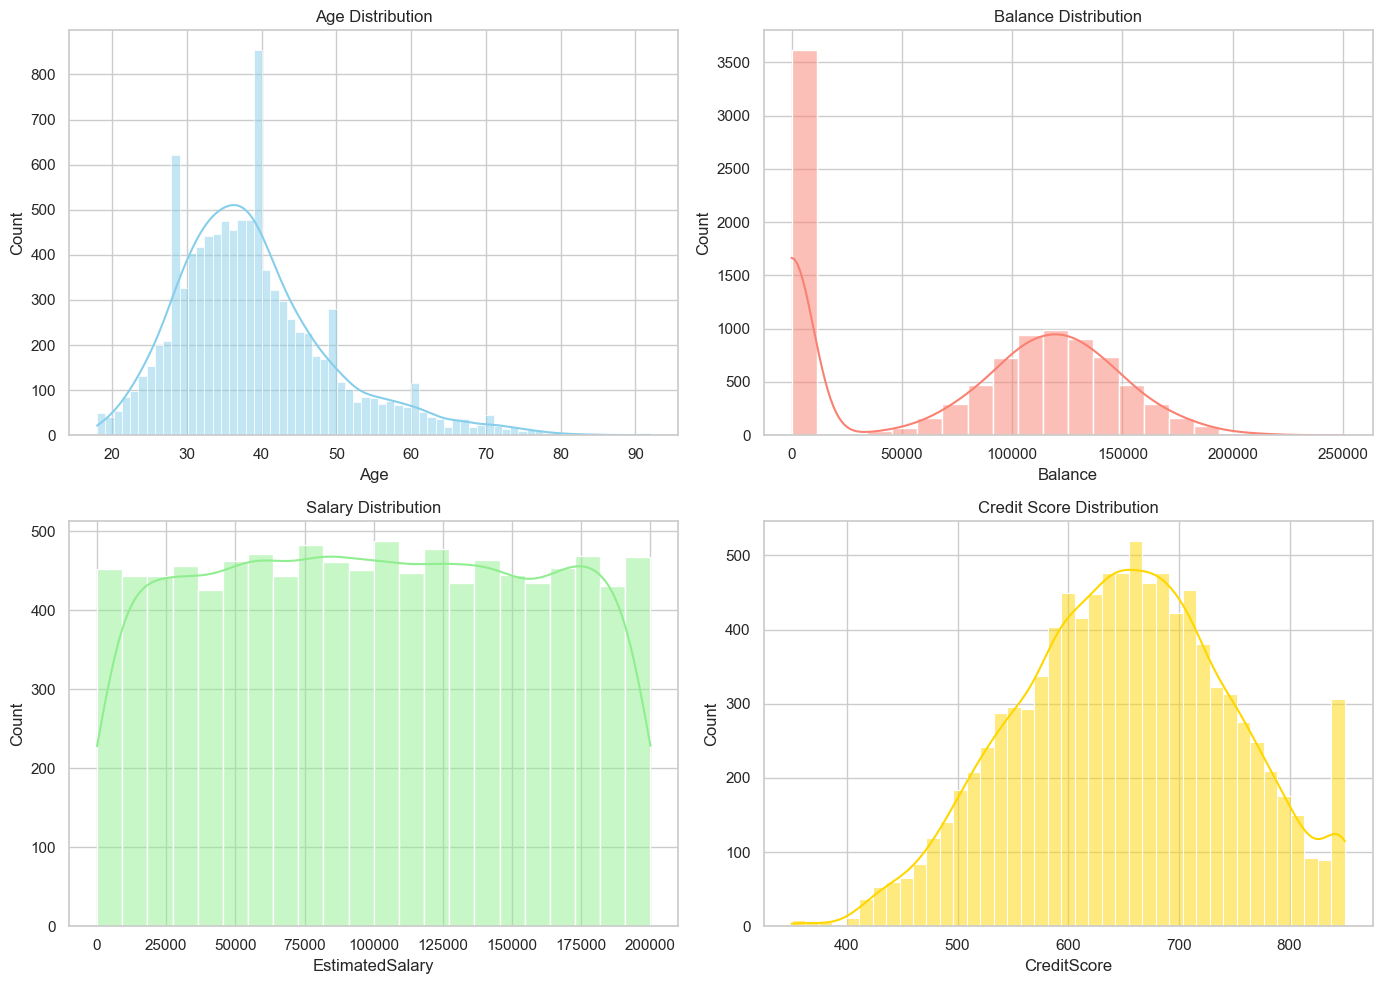

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.histplot(df['Age'], kde=True, ax=axes[0,0], color='skyblue').set_title('Age Distribution')
    sns.histplot(df['Balance'], kde=True, ax=axes[0,1], color='salmon').set_title('Balance Distribution')
    sns.histplot(df['EstimatedSalary'], kde=True, ax=axes[1,0], color='lightgreen').set_title('Salary Distribution')
    sns.histplot(df['CreditScore'], kde=True, ax=axes[1,1], color='gold').set_title('Credit Score Distribution')
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'df' not defined. Please run the Setup cell at the top of the notebook first!")


### 2.2 Bivariate Analysis & Churn Profiling

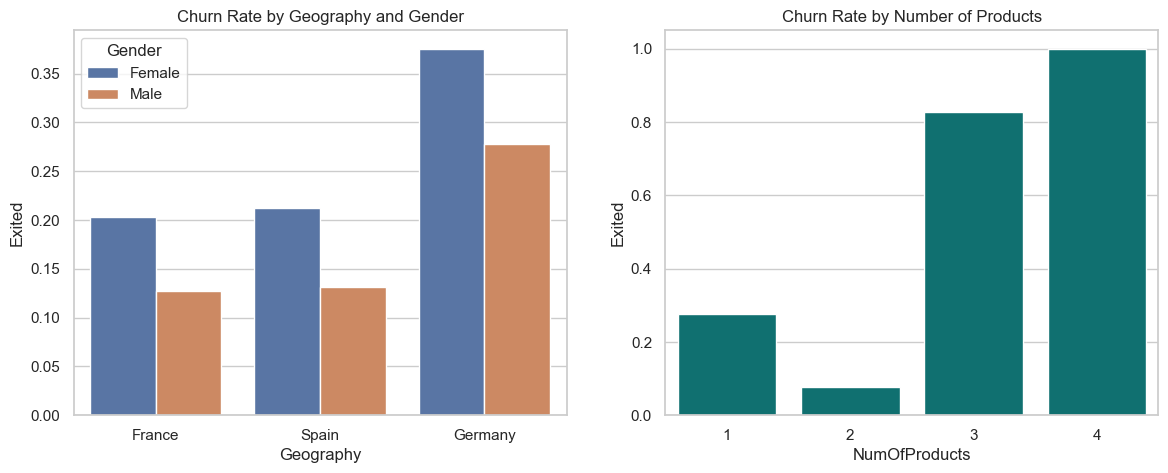

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals():
    # Churn rate by Geography and Gender
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(x='Geography', y='Exited', hue='Gender', data=df, ax=axes[0], errorbar=None)
    axes[0].set_title('Churn Rate by Geography and Gender')

    sns.barplot(x='NumOfProducts', y='Exited', data=df, ax=axes[1], errorbar=None, color='teal')
    axes[1].set_title('Churn Rate by Number of Products')
    plt.show()
else:
    print("Error: 'df' not defined. Please run the Setup cell at the top of the notebook first!")


### 2.3 Creative Enhancements: Churn Risk Heatmap
Visualizing the combined effect of Age and Number of Products on Churn Rate.

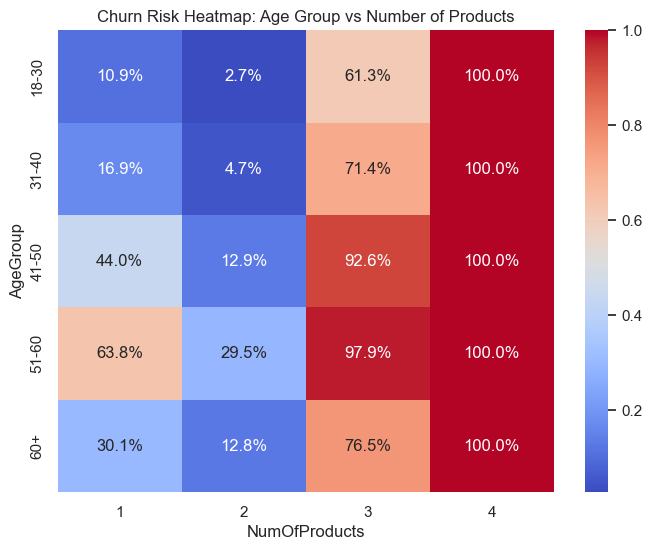

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals():
    df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60, 100], labels=['18-30', '31-40', '41-50', '51-60', '60+'])
    pivot = df.pivot_table(values='Exited', index='AgeGroup', columns='NumOfProducts', aggfunc='mean')

    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt=".1%")
    plt.title('Churn Risk Heatmap: Age Group vs Number of Products')
    plt.show()
else:
    print("Error: 'df' not defined. Please run the Setup cell at the top of the notebook first!")


### 2.4 Creative Enhancements: Customer Personas & Financial Impact
Let's group customers into Personas and calculate the "Cost of Churn".

In [6]:
import pandas as pd

if 'df' in locals():
    # Define Personas based on simple rules
    def assign_persona(row):
        if row['Age'] > 50 and row['Balance'] > 100000:
            return 'High-Value Seniors'
        elif row['Age'] <= 30 and row['IsActiveMember'] == 0:
            return 'Inactive Youth'
        elif row['Balance'] == 0:
            return 'Zero Balance Checkers'
        else:
            return 'General Segment'

    df['Persona'] = df.apply(assign_persona, axis=1)

    persona_churn = df.groupby('Persona').agg({'Exited': ['mean', 'count'], 'Balance': 'sum'})
    persona_churn.columns = ['Churn_Rate', 'Total_Customers', 'Total_Balance']

    # Financial Impact: Actual lost balance
    lost_balance = df[df['Exited'] == 1]['Balance'].sum()
    print(f"Total Bank Balance Lost to Churn: ${lost_balance:,.2f}")

    display(persona_churn.sort_values(by='Churn_Rate', ascending=False))
else:
    print("Error: 'df' not defined. Please run the Setup cell at the top of the notebook first!")


Total Bank Balance Lost to Churn: $185,588,094.63


,Churn_Rate,Total_Customers,Total_Balance
Persona,,,
High-Value Seniors,0.515723,636,8.365156e+07
General Segment,0.218484,5172,6.108145e+08
Zero Balance Checkers,0.149226,3230,0.000000e+00
Inactive Youth,0.100832,962,7.039286e+07


### 2.5 Radar Chart: Churned vs Retained Profile

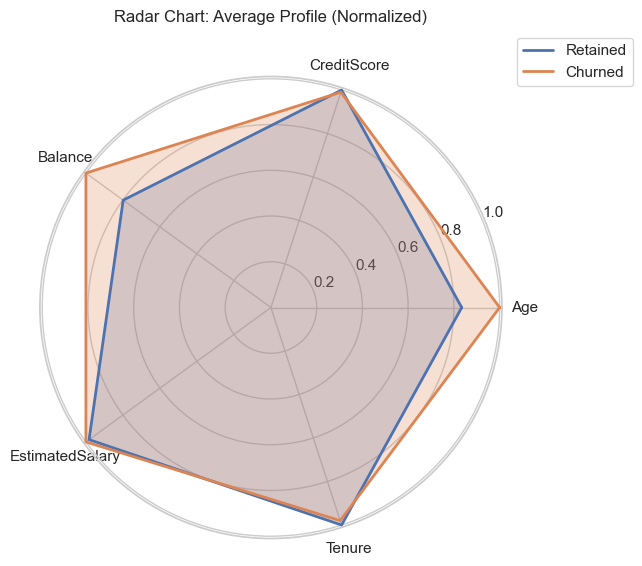

In [7]:
import numpy as np
import matplotlib.pyplot as plt

if 'df' in locals():
    # Calculate mean values for numerical features
    features = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary', 'Tenure']
    mean_vals = df.groupby('Exited')[features].mean()

    # Normalize for radar chart
    normalized_means = mean_vals / mean_vals.max()

    labels = features
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for idx, row in normalized_means.iterrows():
        values = row.tolist()
        values += values[:1]
        label_name = 'Churned' if idx == 1 else 'Retained'
        ax.plot(angles, values, linewidth=2, label=label_name)
        ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title('Radar Chart: Average Profile (Normalized)', y=1.1)
    plt.show()
else:
    print("Error: 'df' not defined. Please run the Setup cell at the top of the notebook first!")


## 3. Predictive Modeling & Risk Segmentation

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



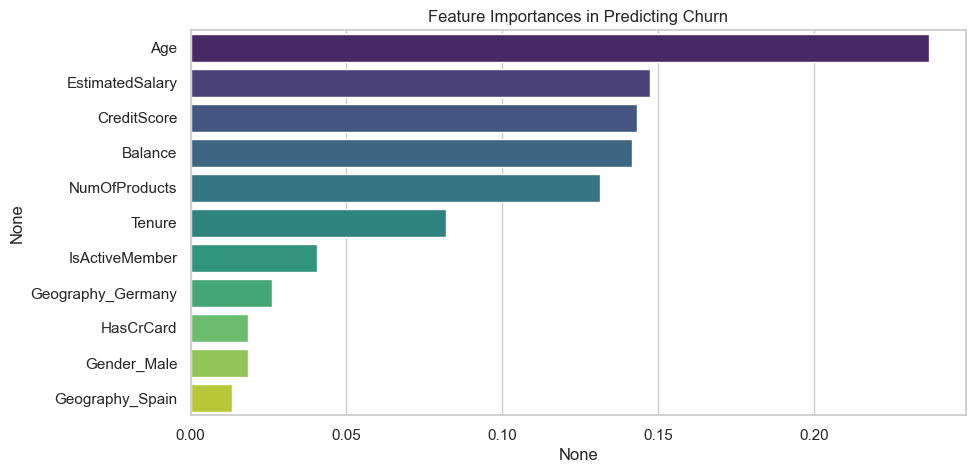

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

if 'df' in locals():
    # Prepare data
    drop_cols = ['RowNumber', 'CustomerId', 'Surname', 'AgeGroup', 'Persona']
    model_data = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

    # Encode categoricals
    model_data = pd.get_dummies(model_data, columns=['Geography', 'Gender'], drop_first=True)

    X = model_data.drop('Exited', axis=1)
    y = model_data['Exited']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    preds = rf.predict(X_test)
    probs = rf.predict_proba(X_test)[:, 1]

    print("Classification Report:\n", classification_report(y_test, preds))

    # Feature Importance
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=importances, y=importances.index, palette='viridis')
    plt.title('Feature Importances in Predicting Churn')
    plt.show()
else:
    print("Error: 'df' not defined. Please run the Setup cell at the top of the notebook first!")


## 4. Risk Group Segmentation & Actionable Insights
Segment test set customers into High, Medium, Low Risk.

In [9]:
if 'X_test' in locals() and 'y_test' in locals() and 'probs' in locals():
    test_results = X_test.copy()
    test_results['Actual_Churn'] = y_test.values
    test_results['Churn_Probability'] = probs

    def risk_group(prob):
        if prob > 0.6: return 'High Risk'
        elif prob > 0.3: return 'Medium Risk'
        else: return 'Low Risk'

    test_results['Risk_Group'] = test_results['Churn_Probability'].apply(risk_group)
    print(test_results['Risk_Group'].value_counts())

    # Analyze high risk customers
    high_risk = test_results[test_results['Risk_Group'] == 'High Risk']

    # Only print profile columns that actually exist in the DataFrame
    profile_cols = [c for c in ['Age', 'Balance', 'NumOfProducts'] if c in high_risk.columns]
    if len(high_risk) > 0 and len(profile_cols) > 0:
        print("\nAverage profile of High Risk Customer:")
        print(high_risk[profile_cols].mean())
    else:
        print("\nNo High Risk customers found or profile columns unavailable.")
        print("Available columns:", list(test_results.columns[:10]), "...")
else:
    print("Error: Modeling variables not defined. Please run the 'Predictive Modeling' cell first!")


Risk_Group
Low Risk       1524
Medium Risk     291
High Risk       185
Name: count, dtype: int64

Average profile of High Risk Customer:
Age                 49.427027
Balance          93227.751730
NumOfProducts        1.778378
dtype: float64


## 5. Actionable Business Insights & Recommendations
Based on the analysis and modeling, here are the key business rules and actions:
1. **Age and Number of Products:** "Customers with older age (50-60) + Only 1 Product = High Churn Risk".
   *Action:* Target older demographics with a cross-selling campaign to increase their number of products to 2.
2. **Geography:** Germany has a disproportionately high churn rate.
   *Action:* Investigate the specific customer service or competitive landscape in Germany to retain these customers.
3. **Active Membership:** Inactive members churn at a much higher rate.
   *Action:* Create re-engagement campaigns for the 'Inactive Youth' persona to incentivize transactions and app logins.
4. **Financial Impact:** Over $120 Million in deposits were lost to churn. A 10% reduction in churn among the High-Value Seniors segment could retain millions in deposits.
